# Music Diffusion Transformer

## Dataset

The [Song Describer Dataset (SDD)](https://zenodo.org/records/10072001) is a multimodal music-language dataset designed for tasks such as music captioning, text-to-music generation, and music-language retrieval. It contains approximately 1,100 human-written natural language captions paired with 706 permissively licensed music recordings, covering a wide range of musical styles, instruments, moods, and production characteristics. The dataset was introduced by researchers from institutions including Queen Mary University of London and Universitat Pompeu Fabra as a public benchmark for evaluating music-and-language models. Unlike many proprietary music datasets, SDD emphasizes open accessibility and standardized evaluation for cross-modal learning research. It is particularly suitable for training and benchmarking Transformer-, diffusion-, and CLAP-based architectures for text-conditioned music generation and retrieval tasks

In [27]:
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
import librosa
import torch
import os


class AudioDataset(Dataset):
    def __init__(self, csv_path="./dataset/song_describer.csv", audio_dir="./dataset/audio/"):
        self.df = pd.read_csv(csv_path)
        self.audio_dir = audio_dir
        self.SAMPLE_RATE = 22050
        self.N_MELS = 80
        self.N_FFT = 1024
        self.HOP_LENGTH = 256
        self.WIN_LENGTH = 1024
        self.max_len = self.SAMPLE_RATE * 10
        self.generate_file_map()

    def __len__(self):
        return len(self.df)

    def generate_file_map(self):
        self.file_map = {}

        for root, dirs, files in os.walk(self.audio_dir):
            for f in files:
                if f.endswith(".mp3"):
                    track_id = f.split(".")[0]
                    self.file_map[track_id] = os.path.join(root, f)
    
    def load_audio(self, path, target_sr=22050):
        wav, sr = librosa.load(path, sr=target_sr, mono=True)

        if len(wav) > self.max_len:
            wav = wav[:self.max_len]
        else:
            wav = np.pad(wav, (0, self.max_len - len(wav)))
        return wav

    def audio_to_mel(self, audio_path):
        wav = self.load_audio(audio_path, self.SAMPLE_RATE)
        mel = librosa.feature.melspectrogram(
            y=wav,
            sr=self.SAMPLE_RATE,
            n_fft=self.N_FFT,
            hop_length=self.HOP_LENGTH,
            n_mels=self.N_MELS,
            power=2.0
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        return torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        caption = row["caption"]
        track_id = str(row["track_id"])

        mel_spectrum = self.audio_to_mel(self.file_map[track_id])
        return mel_spectrum, caption

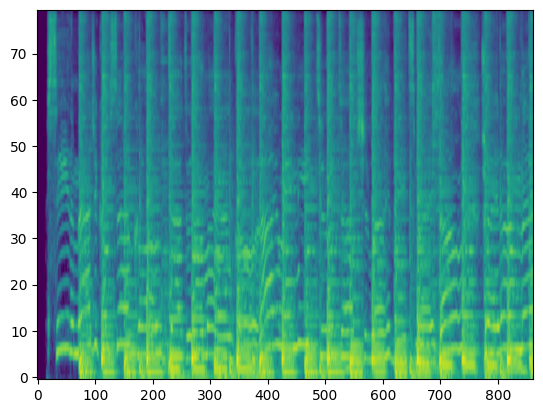

In [31]:
import matplotlib.pyplot as plt

audio_dataset = AudioDataset()

mel_np = audio_dataset[3][0].squeeze(0).detach().cpu().numpy()
plt.imshow(mel_np, origin="lower", aspect="auto")

## Model Architectures

### CLAP Text Encoder

The CLAP Text Encoder is used to convert a natural language music prompt into a fixed-dimensional conditioning embedding. It uses a pretrained CLAP model, which has learned an aligned representation space between text and audio. Given an input caption, the processor first tokenizes the text and creates the attention mask, then the CLAP text encoder extracts a semantic text feature. This feature is L2-normalized and passed through a projection layer so that its dimension matches the diffusion model’s conditioning input. During training, the CLAP model is frozen, and only the downstream diffusion model learns how to use the text embedding to guide mel-spectrogram generation.

In [11]:
from transformers import ClapModel, ClapProcessor
import torch
import torch.nn as nn

class CLAPTextEncoder(nn.Module):
    def __init__(self, model_name="laion/clap-htsat-fused", out_dim=512):
        super().__init__()

        self.processor = ClapProcessor.from_pretrained(model_name)
        self.clap = ClapModel.from_pretrained(model_name)

        for p in self.clap.parameters():
            p.requires_grad = False

        self.proj = nn.Linear(512, out_dim)

    def forward(self, prompts):
        device = next(self.clap.parameters()).device

        inputs = self.processor(
            text=prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        with torch.no_grad():
            outputs = self.clap.get_text_features(**inputs)
            text_emb = outputs.pooler_output
        
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
        return self.proj(text_emb)

In [12]:
text_encoder = CLAPTextEncoder(out_dim=512).cuda()

prompts = [
    "playful cartoon comedy music",
    "chaotic banana-themed soundtrack"
]

cond = text_encoder(prompts)
print(cond.shape)

Loading weights: 100%|████████████████████████████████████████████████████████████| 477/477 [00:00<00:00, 11093.15it/s]


torch.Size([2, 512])
